## Simulating traffic and saltwater intrusion
In this notebook, we simulate a lock complex on a network. Like in notebooks 204 and 205, randomly generated, evenly sized vessels sampled from an exponential distribution have to pass this lock. We add a complex lock object to the graph. Vessels are levelled in the same lock operation if they can fit inside the lock and register with the lock operator before the start of the lock operation. We now include a tidal water level at one side of the lock, and we will observe the levelling times to fluctuate. Moreover, we salt concentrations on both sides of the lock. Due to the lock operation, levelling and gate-open phases emerge that cause salt transport. We quantify the fluxes based on the [pyZSF](https://pypi.org/project/pyzsf/) package of Deltares using a method called the [Zeesluisformulering](https://github.com/Deltares/D-SLF) (translated to English: Sea Lock Formulation).

In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
import pyproj
from shapely.geometry import Point, LineString, Polygon
from shapely.ops import transform

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim
from opentnsim.core.utils import create_object
from opentnsim.utils import inspect_object, generate_vessels_from_distribution
from opentnsim.graph import mixins as graph_module
from opentnsim.core.logutils import logbook2eventtable
from opentnsim.core import Identifiable, Movable, VesselProperties, ExtraMetadata
from opentnsim.core.visualizations import generate_vessel_gantt_chart
from opentnsim.graph.mixins import HasMultiDiGraph
from opentnsim.output import HasOutput
from scipy.stats import norm, uniform, expon

# import of modules important for locking
from opentnsim.lock import IsLockChamber, IsLockWaitingArea, IsLockComplex, LockComplexTraversable
from opentnsim.lock.calculations import estimate_lock_capacity, calculate_lock_occupancy, calculate_levelling_time, calculate_water_exchange_fluxes
from opentnsim.lock.logutils import calculate_cycle_information, get_vessel_delays
from opentnsim.lock.visualizations import show_results, plot_saltwater_intrusion
from opentnsim.environment.mixins.hydrodynamics import HydrodynamicData

# package(s) needed for inspecting the output
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# packege(s) needed to create hydrodynamic data
import xarray as xr

print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.4


In [2]:
%load_ext autoreload
%autoreload 2

#### 0. Create environment
We create an environment with a simulation start and stop as parameters.

In [3]:
# start simpy environment
simulation_start = datetime.datetime(2025, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2025, 1, 3, 0, 0, 0)
env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
We create a directed graph, naming the nodes as 'Sea #' and 'Canal #' to distinguish between the saltwater and freshwater sides of the lock.

In [4]:
# define reference systems
wgs84eqd = pyproj.CRS('4087')
wgs84rad = pyproj.CRS('4326')

# define transformer functions
wgs84eqd_to_wgs84rad = pyproj.transformer.Transformer.from_crs(wgs84eqd,wgs84rad,always_xy=True).transform #equidistant wgs84 to radial wgs84
wgs84rad_to_wgs84eqd = pyproj.transformer.Transformer.from_crs(wgs84rad,wgs84eqd,always_xy=True).transform #radial wgs84 to equidistant wgs84

# create a directed graph
graph = nx.DiGraph()

# add nodes
graph.add_node('Sea -1',geometry=transform(wgs84eqd_to_wgs84rad,Point(-25000,0)))
graph.add_node('Sea 0',geometry=transform(wgs84eqd_to_wgs84rad,Point(-5000,0)))
graph.add_node('Canal 0',geometry=transform(wgs84eqd_to_wgs84rad,Point(5000,0)))
graph.add_node('Canal 1',geometry=transform(wgs84eqd_to_wgs84rad,Point(25000,0)))

# add edges
graph.add_edge('Sea -1','Sea 0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-25000, 0),Point(-5000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('Sea 0','Sea -1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(-25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('Sea 0','Canal 0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(-5000, 0),Point(5000, 0)])), weight=1, length_m=10000)
graph.add_edge('Canal 0','Sea 0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(-5000, 0)])), weight=1, length_m=10000)
graph.add_edge('Canal 0','Canal 1', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(5000, 0),Point(25000, 0)])), weight=1, length_m=25000-5000)
graph.add_edge('Canal 1','Canal 0', geometry = transform(wgs84eqd_to_wgs84rad, LineString([Point(25000, 0),Point(5000, 0)])), weight=1, length_m=25000-5000)

# add graph to environment
env.graph = graph

In [5]:
graph_module.plot_graph(graph)

#### 1+ Adding environmental data
We add the environmental data. The water level at sea is tidal, while the canal has a constant water level. We also have to specify Salinity and Temperature, which we assume are constant on both sides.

In [6]:
hydrodynamic_data = xr.Dataset()

stations = ['Canal 0', 'Sea 0']
time = pd.date_range(start = simulation_start,
                     end = simulation_stop,
                     freq = pd.Timedelta(minutes=5))


# Water level
static_water_level = np.zeros(len(time))
tidal_amplitude = 1.0
tidal_period = 12.5 #hours
tidal_water_level = [tidal_amplitude*np.sin(2*np.pi*(t-simulation_start).total_seconds()/(tidal_period*3600)) for t in time]
water_level_data = xr.DataArray(data=[static_water_level,tidal_water_level],coords={'STATION':stations,'TIME':time})
hydrodynamic_data['Water level'] = water_level_data

# Salinity
static_salinity_sea = 25.0*np.ones(len(time))
static_salinity_canal = 5.0*np.ones(len(time))
salinity_data = xr.DataArray(data=[static_salinity_canal,static_salinity_sea],coords={'STATION':stations,'TIME':time})
hydrodynamic_data['Salinity'] = salinity_data

# Water temperature
static_temperature_sea = 15.0*np.ones(len(time))
static_temperature_canal = 15.0*np.ones(len(time))
temperature_data = xr.DataArray(data=[static_temperature_canal,static_temperature_sea],coords={'STATION':stations,'TIME':time})
hydrodynamic_data['Temperature'] = temperature_data

We add the data to the environment:

In [7]:
HydrodynamicData(env=env, hydrodynamic_data = hydrodynamic_data);

#### 1+ Adding infrastructure
We add the lock complex:

In [8]:
lock_chamber = IsLockChamber(env=env,
                             lock_depth = 10,
                             name='Lock',
                             gate_open = 'Sea 0',
                             edge = ('Sea 0','Canal 0'),
                             geometry_m = Polygon([Point(-200, -25),Point(-200, 25),Point(200, 25),Point(200, -25)]))

In [9]:
# The minimum required input for a lock complex are waiting areas at both sides of the lock
waiting_area_A = IsLockWaitingArea(env=env,
                                   name = 'Waiting area A',
                                   edge = ('Sea 0','Canal 0'),
                                   distance_from_edge_start = 0)

waiting_area_B = IsLockWaitingArea(env=env,
                                   name = 'Waiting area B',
                                   edge = ('Canal 0','Sea 0'),
                                   distance_from_edge_start = 0)

In [10]:
lock_complex = IsLockComplex(lock_chambers = [lock_chamber],
                             waiting_areas = [waiting_area_A, waiting_area_B],
                             registration_nodes = ['Sea 0','Canal 0'],
                             env=env,
                             name = 'Lock complex',)

#### 2. Create agents
And create agents:

In [11]:
# make your preferred Vessel class out of available mix-ins.
Vessel = create_object(
    "Vessel", 
    (
        LockComplexTraversable,     # allows to interact with a lock
        Identifiable,               # allows to give the object a name and a random ID,
        Movable,                    # allows the object to move, with a fixed speed, while logging this activity
        VesselProperties,           # allows vessel to have dimensions, namely a length (L), width (B), and draught (T)
        ExtraMetadata,              # allow additional information, such as an arrival time (required for passing a lock)
        HasMultiDiGraph,            # allow to operate on a graph that can include parallel edges from and to the same nodes
        HasOutput,                  # allow additional output to be stored
    ), 
)

In [12]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel.
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    while True:
        yield from vessel.move()
        
        if vessel.geometry == nx.get_node_attributes(env.graph, "geometry")[vessel.route[-1]]:
            break

In [13]:
upstream_vessels = generate_vessels_from_distribution(env=env,
                                                      VesselClass = Vessel,
                                                      vessel_parameters = {'v':4, 'L':100, 'B':20, 'T':5, 'type':'tanker'},
                                                      mean_arrival_rate=30.,
                                                      number_of_vessels=10,
                                                      start_node = 'Sea -1',
                                                      end_node = 'Canal 1',
                                                      seed = 123)

downstream_vessels = generate_vessels_from_distribution(env=env,
                                                        VesselClass = Vessel,
                                                        vessel_parameters = {'v':4, 'L':100, 'B':20, 'T':5, 'type':'tanker'},
                                                        mean_arrival_rate=30.,
                                                        number_of_vessels=10,
                                                        start_node = 'Canal 1',
                                                        end_node = 'Sea -1',
                                                        seed = 456)

vessels = upstream_vessels + downstream_vessels

for vessel in vessels:
    env.process(mission(env, vessel))

#### 3. Run simulation

In [14]:
env.run()

756
1109
1463
1787
2040
2226
2445
2721


#### 4. Inspect output

#### Gantt chart of event table

In [15]:
df_eventtable = opentnsim.core.logutils.logbook2eventtable([*vessels, lock_chamber])
fig = generate_vessel_gantt_chart(df_eventtable)

#### Time-distance diagram of vessels passing the lock and planning info

In [16]:
def cm_to_pixels(cm):
    return cm * 37.8 # Set figure height to 10 cmfig.update_layout(height=cm_to_pixels(10))

# We can plot the time-distance diagram
fig = lock_chamber.plot(xlimmin = -6050, 
                        xlimmax = 6050,
                        ylimmin = pd.Timestamp('2025-01-01 00:00:00'),
                        ylimmax = pd.Timestamp('2025-01-01 09:00:00'),
                        method='Plotly',
                        boundary_nodes = ['Sea -1','Canal 1'])

fig.update_layout(height=cm_to_pixels(20))

(0.0, 2000.0)

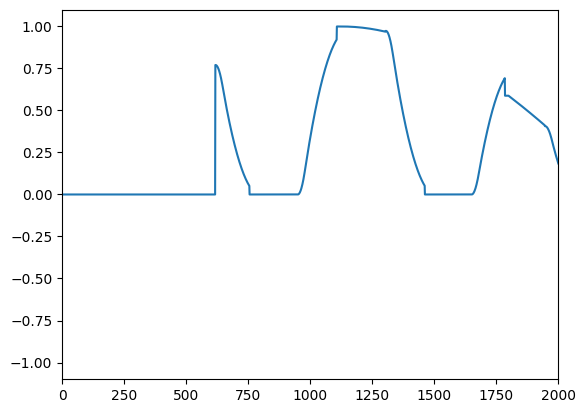

In [22]:
plt.plot(lock_chamber.water_level)
plt.xlim(0,2000)

#### Saltwater intrusion
We can now calculate and visualise saltwater intrusion using the [pyzsf-library](https://github.com/Deltares/D-SLF) developed by Deltares

In [17]:
ZSF_results = calculate_water_exchange_fluxes(lock_chamber)
ZSF_results

ValueError: All arrays must be of the same length

In [ ]:
t_exch = 2*lock_chamber.lock_length/ZSF_results.loc[2].exchange_current_velocity

In [ ]:
1-(ZSF_results.loc[2].saltmass_lock_b - 1000000.0)/(ZSF_results.loc[2].saltmass_lock_a-1000000.0)

In [ ]:
3995197.5791161964/2000000.0

In [ ]:
calculate_lock_salinity_and_saltmass(lock_chamber, ZSF_results)

In [ ]:
lock_chamber.salinity

In [ ]:
math.tanh(t_open/1282.979926436439)

In [ ]:
ZSF_results.loc[2].saltmass_lock_a - lock_volume*ZSF_results.loc[2].salinity_lake

In [ ]:
import math
dt = 300.
exchs = []
time = np.arange(0.,t_open-dt,dt)
for t in time:
    exchs.append(math.tanh(t/t_exch))

In [ ]:
plt.plot(time,exchs)

In [ ]:
plot_saltwater_intrusion(lock_chamber, ZSF_results)

In [ ]:
import pyzsf as ZSF

In [ ]:
zsf = ZSF.ZSFUnsteady(sal_lock=15., head_lock = 0.)

In [ ]:
results = zsf.step_phase_2(t_open_lake=300.)

In [ ]:
zsf.state

In [ ]:
import pprint
pprint.pprint(results)

In [ ]:
dir(ZSF)

In [ ]:
dir(ZSF.pyzsf.ffi)

In [ ]:
ZSF.pyzsf.lib.zsf_param_default(None)

In [ ]:
dir(ZSF)

In [ ]:
hydromanager = HydrodynamicData
hydromanager.hydrodynamic_data.TIME